## WALKING-CLIFF Sarsa

### Alberto Bono 3962994

Importing required modules

In [126]:
from abc import ABC, abstractmethod
import random
import sys
import gym

Building the environment model (simulator)

In [127]:
class BaseEnvironment(ABC):
    
    @abstractmethod
    # Override this method to return the set of states
    def get_states(self):
        pass
    
    @abstractmethod
    # Override this method to return the set of actions available in the state
    def get_actions(self, state):
        pass
    
    @abstractmethod
    def get_all_actions(self):
        pass
    
    @abstractmethod
    # Ovveride this method to implement action execution
    def do_action_and_get_reward(self, action):
        pass

Action Space: The actions available to the agent in each state are defined as follows:

- UP: Move one step upwards.
- DOWN: Move one step downwards.
- LEFT: Move one step to the left.
- RIGHT: Move one step to the right.
- STAY: Stay in the current position.

Observation Space: The agent's observation space is defined by the grid of the environment. Each cell in the grid represents a state, and the agent's position within the grid is its current observation.

Episode Start: Each episode starts with the agent positioned at the bottom-left corner of the grid, i.e., (3, 0).

Rewards:

- Moving into a cliff cell (bottom row except for the starting and ending points) results in a reward of -100.
- Moving into any other cell incurs a reward of -1.
- Reaching the goal cell (bottom-right corner) yields a reward of +10.

Episode End: An episode ends when the agent reaches the goal cell (3, 11) or steps into a cliff cell, resulting in a reward of -100.

In [128]:
class WalkingCliff(BaseEnvironment):
    # Define actions as tuples representing movement directions
    UP = (-1,0)
    DOWN = (1,0)
    LEFT = (0,-1)
    RIGHT = (0,1)
    STAY = (0,0)
    
    # Define labels for actions
    label = {(-1,0):"UP", (1,0):"DOWN", (0,-1):"LEFT", (0,1):"RIGHT", (0,0):"STAY"}
    
    def __init__(self):
         # Initialize the environment with states and actions
        self.states = list()
        for ri in range(4):
            for co in range(12):
                self.states.append((ri,co))
                
        # Define actions for each state
        self.actions = dict()
        self.actions[(0,0)] = [WalkingCliff.RIGHT, WalkingCliff.DOWN]
        self.actions[(0,11)] = [WalkingCliff.LEFT, WalkingCliff.DOWN]
        for i in range(1,11): 
            self.actions[(0,i)] = [WalkingCliff.RIGHT, WalkingCliff.LEFT, WalkingCliff.DOWN]
            self.actions[(1,i)] = [WalkingCliff.RIGHT, WalkingCliff.LEFT, WalkingCliff.DOWN,WalkingCliff.UP]
            self.actions[(2,i)] = [WalkingCliff.RIGHT, WalkingCliff.LEFT, WalkingCliff.DOWN,WalkingCliff.UP]
            #cliff
            self.actions[(3,i)] = [WalkingCliff.DOWN,WalkingCliff.STAY, WalkingCliff.LEFT, WalkingCliff.UP]
            
        for j in range(1,3):
            self.actions[(j,0)] = [WalkingCliff.RIGHT, WalkingCliff.UP, WalkingCliff.DOWN]
            self.actions[(j,11)] = [WalkingCliff.LEFT, WalkingCliff.DOWN,WalkingCliff.UP]
        self.actions[(3,0)] = [WalkingCliff.RIGHT, WalkingCliff.UP]
        self.actions[(3,11)] = [WalkingCliff.STAY, WalkingCliff.LEFT, WalkingCliff.UP]
        # Define all possible actions
        self.all_actions = [WalkingCliff.STAY, WalkingCliff.RIGHT, WalkingCliff.LEFT, WalkingCliff.DOWN, WalkingCliff.UP]
        # Initialize the current state
        self.current_state = (3,0)
    
    def get_states(self):
        return self.states
        
    def get_actions(self, state):
        return self.actions[state]
    
    def get_all_actions(self, state):
        return self.all_actions
    
    def transition(self, current_state, action):
        return (current_state[0] + action[0], current_state[1] + action[1]) 
    
    def do_action_and_get_reward(self, action):
        # If the action is not executable in the state, do nothing and return reward 0
        if action not in self.get_actions(self.current_state):
            return 0
        # Compute the next state based on the action
        self.current_state = self.transition(self.current_state, action)
        
        # If the agent moves into a cliff cell, reset and return reward -100
        if self.current_state[0]== 3 and 1<= self.current_state[1]<=10:
            self.reset()
            return -100
        # If the agent reaches the goal cell, return reward 10
        elif (self.current_state == (3,11)):
            return 10
        # For all other states, return reward -1
        else:
            return -1
        
    def task_done(self):
        # Check if the task is done (agent reached the goal state)
        return self.current_state == (3, 11)
    
    def reset(self):
        # Reset the environment (agent position to starting point)
        self.current_state = (3, 0)

## Computing policies

Base class for all policies. The method apply enforces the policy, the method update changes the policy.

In [129]:
#SARSA and Q_Learning do not update
#the policy straight away( no update method)
class BasePolicy(ABC):
    
    @abstractmethod
    # Ovveride this method to implement policy application
    # Returns the action given the state
    def apply(self, state):
        pass

A concrete policy to initialize the search for an optimal policy. Implements an  𝜖
 -greedy technique for action choice.


The Epsilon-Greedy policy is a common strategy used in reinforcement learning to balance exploration and exploitation. It allows the agent to explore new actions (exploration) while also exploiting its current knowledge to choose actions that are estimated to be the best (exploitation).

Epsilon Parameter: The Epsilon-Greedy policy addresses the exploration-exploitation trade-off by introducing an epsilon parameter (ε). This parameter determines the balance between exploration and exploitation. Epsilon is a value between 0 and 1.

With probability ε (epsilon), the agent chooses to explore by selecting a random action from the set of available actions. This encourages the agent to try out new actions and gather more information about the environment.
With probability 1 - ε, the agent chooses to exploit its current knowledge by selecting the action with the highest estimated value obtained from Q-table

When ε is high (close to 1), the agent is more likely to explore and select random actions. This can be beneficial during the early stages of learning when the agent's knowledge about the environment is limited.
When ε is low (close to 0), the agent is more likely to exploit and select actions based on its current knowledge. This is advantageous when the agent has learned a good approximation of the optimal policy and wants to maximize rewards based on its existing knowledge.

As the agent interacts with the environment and receives reward  it updates the Q-table based on the observed outcomes. Over time, the agent learns to strike a balance between exploration and exploitation to maximize its cumulative rewards.

In [130]:
class EpsilonGreedyPolicy(BasePolicy):
    #We need to have access to the simulator and the Q_Table
    def __init__(self, environment, Q_table, epsilon):
        self.environment = environment
        self.Q_table = Q_table
        self.epsilon = epsilon
    
    # Apply the policy to select an action given the current state
    def apply(self, state):
        #Get all the action available in the state
        actions = self.environment.get_actions(state)
        #Let's extract a random number between 0 and 1 
        #(Hp. 0 epsilon < 1, so prob. of extracting a number less than epsilon is epsilon)
        if random.random() < self.epsilon:
            # Choose an action at random with probability epsilon
            return random.choice(actions)
        else:
            # Choose the best action accordin to Q_table with probability 1-epsilon
            # If all actions have the same Q-value then break ties randomly
            max_action_value = -1* sys.float_info.max
            best_action = random.choice(actions)
            for action in actions:
                if self.Q_table[state][action] > max_action_value:
                    max_action_value = self.Q_table[state][action]
                    best_action = action
            return action

## SARSA algorithm (on-policy reinforcement Learning)

SARSA (State-Action-Reward-State-Action) is an on-policy temporal difference reinforcement learning algorithm. It learns the Q-values (action values) for each state-action pair based on the observed transitions and rewards. SARSA updates the Q-values using the observed transitions in a sample episode.



In [131]:
class SARSA:
    # Initialize the SARSA algorithm with the environment
    # gamma := discount factor for discounted sum of rewards
    # alpha := step size parameter for appproximate solution of Bellman eq.
    # epsilon := the parameter for epsilom greedy policy
    # episodes := number of episodes to try
    def __init__(self, environment, gamma, alpha, epsilon, episodes):
        self.environment = environment
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.episodes = episodes
        self.Q_table = dict() # Initialize Q-table to store state-action values
        # Initialize the value of each state-action pair to 0
        #Initialize the Q_table as map of maps:
        #- each state maps to a map of actions
        #-each action maps to a value
        for state in environment.get_states():
            self.Q_table[state] = dict()
            for action in environment.get_actions(state):
                self.Q_table[state][action] = 0
        # Use epsilon-greedy policy for learning
        self.policy = EpsilonGreedyPolicy(environment, self.Q_table, epsilon)
        
    # Apply the SARSA algorithm to learn and update the Q-values       
    def apply(self):
        
        for e in range(self.episodes):
            self.episode_length=0
            state = self.environment.current_state 
            action = self.policy.apply(self.environment.current_state) 
            while not self.environment.task_done() :
                reward = self.environment.do_action_and_get_reward(action)
                next_state = self.environment.current_state
                next_action = self.policy.apply(next_state)
                temp_diff = self.Q_table[next_state][next_action] - self.Q_table[state][action]
                self.Q_table[state][action] =\
                self.Q_table[state][action] + self.alpha * (reward + self.gamma * temp_diff) 
                state = next_state
                action = next_action
                self.episode_length +=1
            
            # Must reset the environment before trying another episode
            self.environment.reset()
            print(f'Episode {e+1},Length: {self.episode_length}')

## Experimenting the SARSA algorithm

In [141]:
Walking_Cliff = WalkingCliff()
# gamma 0.9
# alpha = 0.2
# epsilon = 0.1 
# Is there a better choice? Maybe, need to experiment with grid search
sarsa = SARSA(Walking_Cliff, 0.9, 0.2, 0.1, 1000)

In [142]:

sarsa.apply()


Episode 1,Length: 30451
Episode 2,Length: 90389
Episode 3,Length: 13793
Episode 4,Length: 10943
Episode 5,Length: 4302
Episode 6,Length: 34438
Episode 7,Length: 15167
Episode 8,Length: 15690
Episode 9,Length: 8527
Episode 10,Length: 12887
Episode 11,Length: 6167
Episode 12,Length: 24950
Episode 13,Length: 24945
Episode 14,Length: 36055
Episode 15,Length: 16487
Episode 16,Length: 21856
Episode 17,Length: 38857
Episode 18,Length: 72028
Episode 19,Length: 12167
Episode 20,Length: 34020
Episode 21,Length: 19144
Episode 22,Length: 89023
Episode 23,Length: 33682
Episode 24,Length: 36658
Episode 25,Length: 35774
Episode 26,Length: 40872
Episode 27,Length: 23963
Episode 28,Length: 46113
Episode 29,Length: 64579
Episode 30,Length: 45349
Episode 31,Length: 8426
Episode 32,Length: 2037
Episode 33,Length: 52790
Episode 34,Length: 47063
Episode 35,Length: 49350
Episode 36,Length: 120766
Episode 37,Length: 27491
Episode 38,Length: 130237
Episode 39,Length: 14285
Episode 40,Length: 122160
Episode 41,

Episode 324,Length: 28714
Episode 325,Length: 39657
Episode 326,Length: 13002
Episode 327,Length: 64609
Episode 328,Length: 8382
Episode 329,Length: 20292
Episode 330,Length: 113088
Episode 331,Length: 70104
Episode 332,Length: 40652
Episode 333,Length: 43957
Episode 334,Length: 48607
Episode 335,Length: 78172
Episode 336,Length: 179858
Episode 337,Length: 30291
Episode 338,Length: 36679
Episode 339,Length: 116425
Episode 340,Length: 71425
Episode 341,Length: 18173
Episode 342,Length: 3921
Episode 343,Length: 55118
Episode 344,Length: 6115
Episode 345,Length: 11327
Episode 346,Length: 66308
Episode 347,Length: 27022
Episode 348,Length: 4412
Episode 349,Length: 69602
Episode 350,Length: 17369
Episode 351,Length: 17064
Episode 352,Length: 64709
Episode 353,Length: 1861
Episode 354,Length: 32392
Episode 355,Length: 68205
Episode 356,Length: 25112
Episode 357,Length: 33730
Episode 358,Length: 11182
Episode 359,Length: 4847
Episode 360,Length: 10799
Episode 361,Length: 75566
Episode 362,Len

Episode 641,Length: 47716
Episode 642,Length: 32816
Episode 643,Length: 47427
Episode 644,Length: 47332
Episode 645,Length: 61308
Episode 646,Length: 3886
Episode 647,Length: 1804
Episode 648,Length: 27808
Episode 649,Length: 17728
Episode 650,Length: 36800
Episode 651,Length: 84965
Episode 652,Length: 13986
Episode 653,Length: 13117
Episode 654,Length: 1052
Episode 655,Length: 58960
Episode 656,Length: 7994
Episode 657,Length: 59483
Episode 658,Length: 45317
Episode 659,Length: 3845
Episode 660,Length: 121639
Episode 661,Length: 19867
Episode 662,Length: 9298
Episode 663,Length: 51388
Episode 664,Length: 1753
Episode 665,Length: 21567
Episode 666,Length: 78412
Episode 667,Length: 95653
Episode 668,Length: 21045
Episode 669,Length: 28113
Episode 670,Length: 76967
Episode 671,Length: 59699
Episode 672,Length: 85404
Episode 673,Length: 61585
Episode 674,Length: 45783
Episode 675,Length: 28916
Episode 676,Length: 16651
Episode 677,Length: 33777
Episode 678,Length: 50544
Episode 679,Length

Episode 960,Length: 101656
Episode 961,Length: 82518
Episode 962,Length: 3913
Episode 963,Length: 2121
Episode 964,Length: 4813
Episode 965,Length: 55802
Episode 966,Length: 42562
Episode 967,Length: 4189
Episode 968,Length: 166867
Episode 969,Length: 19113
Episode 970,Length: 6308
Episode 971,Length: 9117
Episode 972,Length: 19444
Episode 973,Length: 12814
Episode 974,Length: 7819
Episode 975,Length: 41848
Episode 976,Length: 52256
Episode 977,Length: 31031
Episode 978,Length: 61289
Episode 979,Length: 21140
Episode 980,Length: 49427
Episode 981,Length: 2105
Episode 982,Length: 24356
Episode 983,Length: 71660
Episode 984,Length: 33497
Episode 985,Length: 37272
Episode 986,Length: 70823
Episode 987,Length: 13086
Episode 988,Length: 48387
Episode 989,Length: 34669
Episode 990,Length: 16445
Episode 991,Length: 38195
Episode 992,Length: 106225
Episode 993,Length: 40916
Episode 994,Length: 33917
Episode 995,Length: 92758
Episode 996,Length: 42000
Episode 997,Length: 19687
Episode 998,Lengt

The GreedyPolicy class implements a policy that always selects the action with the highest estimated value according to the Q-table.

To avoid reading the Q_table directly, I implement a greedy policy class based on Q_table values: Printing the optimal policy  𝜋∗ based on the  𝑄∗ values approximated by SARSA. Creating a new class for a greedy policy:
  
  

In [143]:

class GreedyPolicy(BasePolicy):
    
    def __init__(self, environment, Q_table):
        self.environment = environment
        self.Q_table = Q_table
        
    def apply(self, state):
        actions = self.environment.get_actions(state)
        max_action_value = -1 * sys.float_info.max
        best_action = None
        for action in actions:
            if self.Q_table[state][action] > max_action_value:
                max_action_value = self.Q_table[state][action]
                best_action = action
        return best_action

In [144]:
greedy_policy = GreedyPolicy(Walking_Cliff, sarsa.Q_table)

As we can see below there is the optimal policy based on q-table

In [145]:
for ri in range(4):
    for co in range(12):
        print(WalkingCliff.label[greedy_policy.apply((ri,co))],end=' ')
    print()

RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT DOWN 
RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT RIGHT DOWN 
UP DOWN DOWN DOWN DOWN DOWN DOWN DOWN DOWN DOWN DOWN STAY 


Printing the values in the  𝑄
 -table:

In [146]:
for ri in range(4):
    for co in range(12):
        print("({},{}):".format(ri,co))
        actions = sarsa.environment.get_actions((ri,co))
        for action in actions:
            print("{} -> {}".format(WalkingCliff.label[action],sarsa.Q_table[(ri,co)][action]))
        print

(0,0):
RIGHT -> -49923.29907283567
DOWN -> -50267.10377837789
(0,1):
RIGHT -> -49780.331003659245
LEFT -> -50258.530633508715
DOWN -> -50079.31922092179
(0,2):
RIGHT -> -49531.320108983375
LEFT -> -50087.2784740302
DOWN -> -49774.556784652326
(0,3):
RIGHT -> -49180.73636828599
LEFT -> -49719.0203388191
DOWN -> -49543.5292675647
(0,4):
RIGHT -> -49004.33237271175
LEFT -> -49428.4098544092
DOWN -> -49255.05717706446
(0,5):
RIGHT -> -48686.18785740125
LEFT -> -49232.36730384449
DOWN -> -48973.98154693435
(0,6):
RIGHT -> -48237.35810213912
LEFT -> -48887.10823148445
DOWN -> -48569.49161913961
(0,7):
RIGHT -> -48097.14943298686
LEFT -> -48641.47106297133
DOWN -> -48227.36593550711
(0,8):
RIGHT -> -47745.11973980593
LEFT -> -48238.93620591522
DOWN -> -47965.55895073336
(0,9):
RIGHT -> -47580.58568547289
LEFT -> -47995.25465714928
DOWN -> -47717.154370108154
(0,10):
RIGHT -> -46837.41160583554
LEFT -> -47749.48870688607
DOWN -> -47398.68262216961
(0,11):
LEFT -> -47567.529570576866
DOWN -> -4

Above there are the values of the Q_table where are the weighted sum of the all reward 

In [147]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import time
class WalkingCliffVisualizer:
    def __init__(self, Walking_Cliff, q_table):
        self.Walking_Cliff = Walking_Cliff
        self.q_table = q_table
        self.fig, self.ax = plt.subplots()

    def plot_grid(self, agent_position):
        self.ax.clear()
        for ri in range(4):
            for co in range(12):
                if co in range(1,11) and ri==3:
                    color = 'red'
                elif (ri, co) == (3,11):
                    color = 'green'
                elif (ri, co) == (3,0):
                    color = 'yellow'
                else:
                    color = 'white'

                rect = patches.Rectangle((co, ri), 1, 1, linewidth=1, edgecolor='black', facecolor=color)
                self.ax.add_patch(rect)
                
        self.ax.text(agent_position[1] + 0.5, agent_position[0] + 0.5, 'Agent', ha='center', va='center', color='blue')

        self.ax.set_xlim(0, 12)
        self.ax.set_ylim(0, 4)
        self.ax.invert_yaxis() 
        display(self.fig)
        clear_output(wait=True)
        time.sleep(0.00003)  

    def animate_agent(self, num_episodes):
        for episode in range(num_episodes):
            self.Walking_Cliff.reset()
            self.Walking_Cliff.current_state = (3, 0)  
            self.Walking_Cliff.get_states()
            
            while not self.Walking_Cliff.task_done():
                state = self.Walking_Cliff.current_state
                #action = GreedyPolicy(self.Walking_Cliff, self.q_table).apply(state)
                action = sarsa.policy.apply(state)
                self.Walking_Cliff.do_action_and_get_reward(action)
                self.plot_grid(self.Walking_Cliff.current_state)
                time.sleep(0.00003)  # Ritardo di 0.3 secondi tra le azioni

        # Mostra la tabella Q alla fine di ogni episodio
        print("Q-table values at the end of episode", episode+1)
        for state, actions in sarsa.Q_table.items():
            print("State:", state)
            for action, value in actions.items():
                print("Action:", WalkingCliff.label[action], "Value:", value)
            print()

        #env.close()

### Run the code below to see the exploiaration of the agent in the gridword under the rule of walking cliff

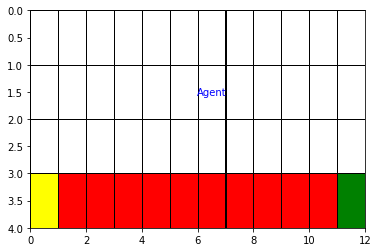

In [ ]:
visualizer = WalkingCliffVisualizer(Walking_Cliff, sarsa.Q_table)
visualizer.animate_agent(num_episodes=1)